# 🎬 Sentiment Analysis on IMDB Movie Reviews

## Project Overview
This notebook performs **sentiment analysis** on 50,000 IMDB movie reviews
using NLP and Machine Learning techniques.

### Steps:
1. Exploratory Data Analysis (EDA)
2. Text Preprocessing
3. Model Building & Comparison
4. Results

  
**Dataset:** [IMDB Dataset - Kaggle](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews)

In [29]:
import kagglehub

# Download IMDB dataset
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)

Path to dataset files: /Users/saugatneupane/.cache/kagglehub/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/versions/1


In [30]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from wordcloud import WordCloud


In [31]:
import kagglehub
import os 

csv_file = os.path.join(path,"IMDB Dataset.csv")

df = pd.read_csv(csv_file)
df.head(15)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
5,"Probably my all-time favorite movie, a story o...",positive
6,I sure would like to see a resurrection of a u...,positive
7,"This show was an amazing, fresh & innovative i...",negative
8,Encouraged by the positive comments about this...,negative
9,If you like original gut wrenching laughter yo...,positive


In [32]:
print("Dataset Info:")
df.info()
print(df['sentiment'].value_counts())
print("\n ? Missing Value:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

 ? Missing Value:
review       0
sentiment    0
dtype: int64


/var/folders/kw/w60pvl0s2nj2rc9ctz6snk540000gq/T/ipykernel_4461/968387650.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='Set2')


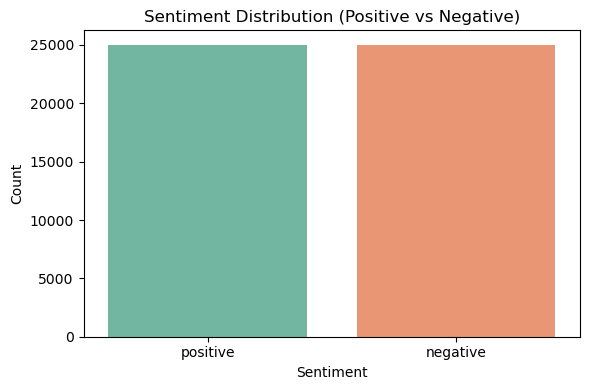

In [33]:
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df, palette='Set2')
plt.title('Sentiment Distribution (Positive vs Negative)')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('sentiment_distribution.png')  # saves for GitHub
plt.show()


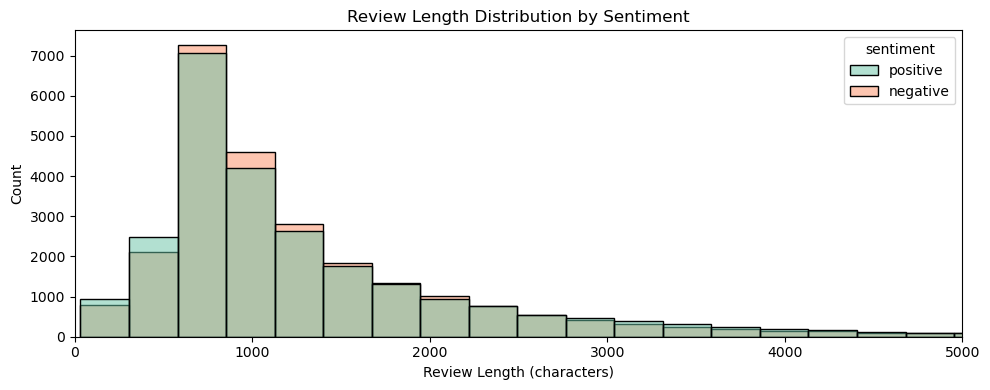

In [34]:
# Add review length column
df['review_length'] = df['review'].apply(len)

plt.figure(figsize=(10,4))
sns.histplot(data=df, x='review_length', hue='sentiment', bins=50, palette='Set2')
plt.title('Review Length Distribution by Sentiment')
plt.xlabel('Review Length (characters)')
plt.ylabel('Count')
plt.xlim(0, 5000)
plt.tight_layout()
plt.savefig('review_length.png')
plt.show()


In [35]:
from wordcloud import WordCloud

ValueError: unknown color specifier: 'white '

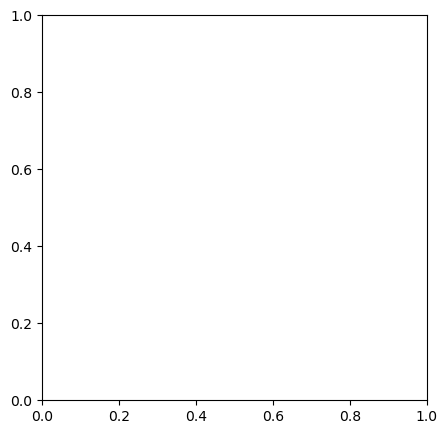

In [36]:
positive_reviews = df[df['sentiment'] == 'positive']['review'].str.cat(sep=' ')

wordcloud = WordCloud(width=800, height=400, 
                      background_color='white ',
                      colormap='Greens').generate(positive_reviews)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Positive Reviews', fontsize=16)
plt.tight_layout()
plt.savefig('wordcloud_positive.png')
plt.show()


In [ ]:
negative_reviews = df[df['sentiment'] == 'negative']['review'].str.cat(sep=' ')

wordcloud = WordCloud(width=800, height=400, 
                      background_color='white',
                      colormap='Reds').generate(negative_reviews)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Negative Reviews', fontsize=16)
plt.tight_layout()
plt.savefig('wordcloud_negative.png')
plt.show()


In [ ]:
import re
import nltk

nltk.download('stopwords')
nltk.download('punkt')

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

print(" Done!")

In [ ]:
# See what a raw review looks like
print("BEFORE CLEANING:")
print(df['review'][0])

In [ ]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Step 1: Remove HTML tags like <br />
    text = re.sub(r'<.*?>', '', text)
    
    # Step 2: Remove special characters & numbers
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    
    # Step 3: Lowercase everything
    text = text.lower()
    
    # Step 4: Split into words
    words = text.split()
    
    # Step 5: Remove stopwords & apply stemming
    words = [stemmer.stem(w) for w in words if w not in stop_words]
    
    # Step 6: Join back into a string
    return ' '.join(words)

print(" Cleaning function ready!")

In [ ]:
sample = df['review'][0]
print("BEFORE:\n", sample[:300])
print("\nAFTER:\n", clean_text(sample)[:300])

In [ ]:
print(" Cleaning all 50,000 reviews... (takes 1-2 mins)")

df['cleaned_review'] = df['review'].apply(clean_text)

print(" All reviews cleaned!")
df[['review', 'cleaned_review']].head(3)

In [ ]:
# Convert positive/negative to 1/0
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print(" Labels encoded!")
print(df['label'].value_counts())

In [ ]:
df.to_csv('cleaned_imdb.csv', index=False)
print(" Cleaned dataset saved as cleaned_imdb.csv!")

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time



In [ ]:
X = df['cleaned_review']
y = df['label']

X_train, X_test , y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(f"training sample: {len(X_train)}")
print(f"testing sample: {len(X_test)}")

In [ ]:
# Machine learning models can't read text
# We convert text → numbers using TF-IDF
tfidf = TfidfVectorizer(max_features=10000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(" TF-IDF done!")
print(f"Matrix shape: {X_train_tfidf.shape}")

In [ ]:
# Dictionary to store all models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes":         MultinomialNB(),
    "Random Forest":       RandomForestClassifier(n_estimators=100)
}

results = {}

for name, model in models.items():
    print(f" Training {name}...")
    
    start = time.time()
    model.fit(X_train_tfidf, y_train)
    end = time.time()
    
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    
    results[name] = {
        "accuracy": round(acc * 100, 2),
        "time": round(end - start, 2),
        "predictions": y_pred
    }
    
    print(f" {name} — Accuracy: {acc*100:.2f}% | Time: {end-start:.2f}s\n")

In [ ]:
names = list(results.keys())
accuracies = [results[m]['accuracy'] for m in names]

plt.figure(figsize=(8,5))
bars = plt.bar(names, accuracies, color=['#2ecc71','#3498db','#e74c3c'])
plt.title('Model Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy (%)')
plt.ylim(80, 100)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.2,
             f'{acc}%', ha='center', fontsize=12)

plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()


In [ ]:
# Plot confusion matrix for Logistic Regression
best_preds = results['Logistic Regression']['predictions']

cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])
plt.title('Confusion Matrix — Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()
print("Confusion matrix saved!")

In [ ]:
print("=" * 50)
print("📊 FINAL MODEL COMPARISON REPORT")
print("=" * 50)

for name in results:
    print(f"\n {name}")
    print(f"   Accuracy : {results[name]['accuracy']}%")
    print(f"   Train Time: {results[name]['time']}s")
    print(classification_report(y_test, results[name]['predictions'],
                                 target_names=['Negative','Positive']))

In [ ]:
def predict_sentiment(review_text):
    cleaned = clean_text(review_text)
    vectorized = tfidf.transform([cleaned])
    prediction = models['Logistic Regression'].predict(vectorized)
    sentiment = " POSITIVE" if prediction[0] == 1 else " NEGATIVE"
    print(f"Review: {review_text}")
    print(f"Sentiment: {sentiment}")

# Try your own reviews!
predict_sentiment("This movie was absolutely amazing! I loved every minute of it.")
predict_sentiment("Worst movie I have ever seen. Complete waste of time.")

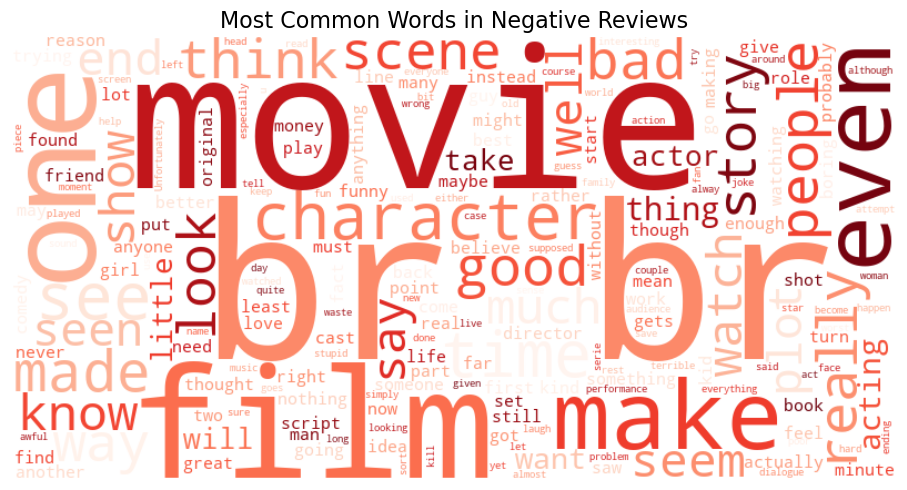

✅ wordcloud_negative.png saved successfully!


In [65]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import os

# Make sure images folder exists
os.makedirs('images', exist_ok=True)

# Generate negative wordcloud
negative_reviews = df[df['sentiment'] == 'negative']['review'].str.cat(sep=' ')

wordcloud = WordCloud(
    width=800, 
    height=400,
    background_color='white',
    colormap='Reds'
).generate(negative_reviews)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Negative Reviews', fontsize=16)
plt.tight_layout()
plt.savefig('images/wordcloud_negative.png', bbox_inches='tight')
plt.show()

# Confirm it saved
if os.path.exists('images/wordcloud_negative.png'):
    print(" wordcloud_negative.png saved successfully!")
else:
    print(" Still not saved — share the error message")